<a href="https://colab.research.google.com/github/Erjg1012/Procesamiento-de-Lenguaje-Natural-PLN-/blob/main/red_neuronal_para_clasificar_rese%C3%B1as%20de%20restaurantes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# importación de librerías

In [ ]:
import pandas as pd
import numpy as np
import re
import nltk
import matplotlib.pyplot as plt
import seaborn as sns
from nltk.corpus import stopwords
from nltk.stem import SnowballStemmer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_selection import SelectKBest, chi2
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import roc_curve, auc


# 1. Cargar datos

In [ ]:
df = pd.read_csv('Restaurant_Reviews.tsv', delimiter='\t')
df['Liked'] = df['Liked'].astype(int)
df

,Review,Liked
0,Wow... Loved this place.,1
1,Crust is not good.,0
2,Not tasty and the texture was just nasty.,0
3,Stopped by during the late May bank holiday of...,1
4,The selection on the menu was great and so wer...,1
...,...,...
995,I think food should have flavor and texture an...,0
996,Appetite instantly gone.,0
997,Overall I was not impressed and would not go b...,0
998,"The whole experience was underwhelming, and I ...",0


#2. limpieza de los datos

Para la limpieza de los datos, se evitó eliminar las stopwords, lematizar el texto y Stemming ya que al probar modelos en esta base de datos se llega a notar que eliminarlos tienden a tener ser perjudiciales, ya que la precisión en los modelos baja.
Por lo que se solo se optó por hacer una limpieza simple, pasando las palabras a minúsculas, eliminado los números y los signos de puntuación (Se conservaron los apostrofes para conservar las contracciones como don't).


In [ ]:
def preprocess_text(text):
    # Eliminar números (dígitos)
    text = re.sub(r'\d+', '', text)
    # Eliminar signos de puntuación (conserva letras, espacios y apóstrofes)
    text = re.sub(r'[^\w\s\']', '', text)
    # Pasar a minúsculas
    text = text.lower()
    return text

df['Cleaned_Review'] = df['Review'].apply(preprocess_text)
df

,Review,Liked,Cleaned_Review
0,Wow... Loved this place.,1,wow loved this place
1,Crust is not good.,0,crust is not good
2,Not tasty and the texture was just nasty.,0,not tasty and the texture was just nasty
3,Stopped by during the late May bank holiday of...,1,stopped by during the late may bank holiday of...
4,The selection on the menu was great and so wer...,1,the selection on the menu was great and so wer...
...,...,...,...
995,I think food should have flavor and texture an...,0,i think food should have flavor and texture an...
996,Appetite instantly gone.,0,appetite instantly gone
997,Overall I was not impressed and would not go b...,0,overall i was not impressed and would not go back
998,"The whole experience was underwhelming, and I ...",0,the whole experience was underwhelming and i t...


# 3. Vectorización y selección de características


Se optó por emplear una vectorización empleando la función TfidfVectorizer ya que en noté que en trabajos pasados esta logró capturar mejor las palabras clave, a diferencia de los embeddings que no llegaron a capturarlos del todo, teniendo rendimientos mas pobres, a comparación del TF-IDF.

Se abrió una ventana de 2 ya que le daba mayor peso a una sola palabra, y al tener una ventana de 2, llegaba a considerar de mejor estas relaciones entre palabras. Llegando a considerar algunas de estas relaciones como importantes. solo se van a tomar las 5000 más utiles.

Para hace runa mejor selección se empleo la función selectkBest que empleó la selección de características (chi2) eliminando ruido  ya que esta solo dejo las mejores 1000


In [ ]:
tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1, 2))
X_tfidf = tfidf.fit_transform(df['Cleaned_Review'])

selector = SelectKBest(chi2, k=1000)
X_selected = selector.fit_transform(X_tfidf, df['Liked'])


# 4. División de datos


Se empleó un 80% de los datos para entrenamiento y un 20% para prueba.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X_selected.toarray(), df['Liked'], test_size=0.2, random_state=42
)


# 5. Modelo MLP


##Distribución del MLP
- Primera capa oculta: 16 neuronas con activación relu
- Regularización: apaga 30% de neuronas aleatoriamente para evitar sobreajustes
- Segunda capa oculta: 8 neuronas con activación relu
- Capa de salida: 1 neurona con funcion de activación sigmoide

##Optimización y compilación del modelo

Adam (Adaptive Moment Estimation) es un algoritmo de optimización que combina:
- Momentum: Acelera el aprendizaje en direcciones relevantes
- RMSProp: Adapta la tasa de aprendizaje por parámetro

###Parámetro clave:

- learning_rate=0.001: Tasa de aprendizaje estándar (valor recomendado por la literatura)

 Más alto: Aprendizaje rápido pero inestable  

 Más bajo: Aprendizaje lento pero estable



In [ ]:
model = Sequential([
    Dense(16, activation='relu', input_shape=(X_train.shape[1],)),
    Dropout(0.3),
    Dense(8, activation='relu'),
    Dense(1, activation='sigmoid')
])

optimizer = Adam(learning_rate=0.001)
model.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['accuracy'])
model.summary()


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 16)             │        16,016 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,161 (63.13 KB)

 Trainable params: 16,161 (63.13 KB)

 Non-trainable params: 0 (0.00 B)

# 6. Entrenamiento

In [ ]:
early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.5280 - loss: 0.6929 - val_accuracy: 0.5750 - val_loss: 0.6916
Epoch 2/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6136 - loss: 0.6880 - val_accuracy: 0.6875 - val_loss: 0.6852
Epoch 3/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7084 - loss: 0.6757 - val_accuracy: 0.7500 - val_loss: 0.6726
Epoch 4/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7713 - loss: 0.6566 - val_accuracy: 0.7500 - val_loss: 0.6532
Epoch 5/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8350 - loss: 0.6177 - val_accuracy: 0.8625 - val_loss: 0.6216
Epoch 6/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8949 - loss: 0.5738 - val_accuracy: 0.8625 - val_loss: 0.5850
Epoch 7/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8776 - loss: 0.5254 - val_accuracy: 0.8625 - val_loss: 0.5450
Epoch 8/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8945 - loss: 0.4712 - val_accuracy: 0.9125 - val_loss

# 7. Evaluación


In [ ]:
test_loss, test_acc = model.evaluate(X_test, y_test)
print(f"\nPrecisión en prueba: {test_acc:.4f}")

y_pred_prob = model.predict(X_test)
y_pred = (y_pred_prob > 0.5).astype("int32")
print("\nReporte de Clasificación:")
print(classification_report(y_test, y_pred))
print("AUC-ROC:", roc_auc_score(y_test, y_pred_prob))



7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9152 - loss: 0.2031 

Precisión en prueba: 0.9100


7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step

Reporte de Clasificación:
              precision    recall  f1-score   support

           0       0.91      0.90      0.91        96
           1       0.91      0.92      0.91       104

    accuracy                           0.91       200
   macro avg       0.91      0.91      0.91       200
weighted avg       0.91      0.91      0.91       200

AUC-ROC: 0.9736578525641026


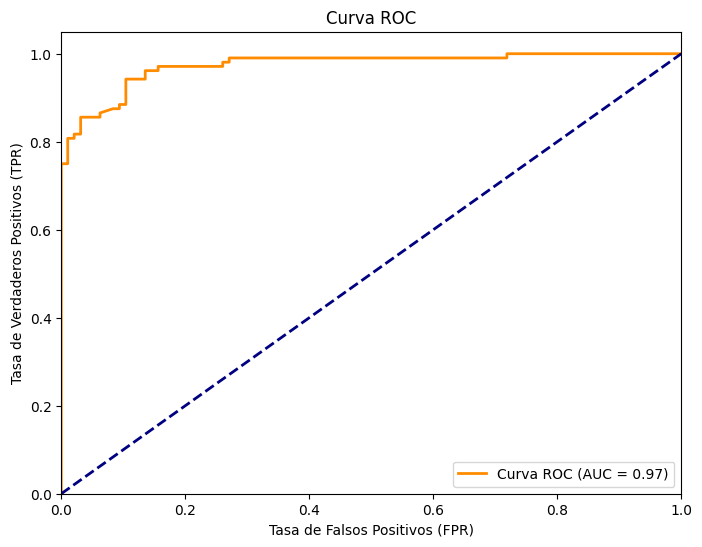

In [ ]:

# Calcular las tasas de falsos positivos y verdaderos positivos
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)
roc_auc = auc(fpr, tpr)  # Calcular el área bajo la curva

# Graficar la curva ROC
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'Curva ROC (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')  # Línea de referencia
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tasa de Falsos Positivos (FPR)')
plt.ylabel('Tasa de Verdaderos Positivos (TPR)')
plt.title('Curva ROC')
plt.legend(loc="lower right")
plt.show()

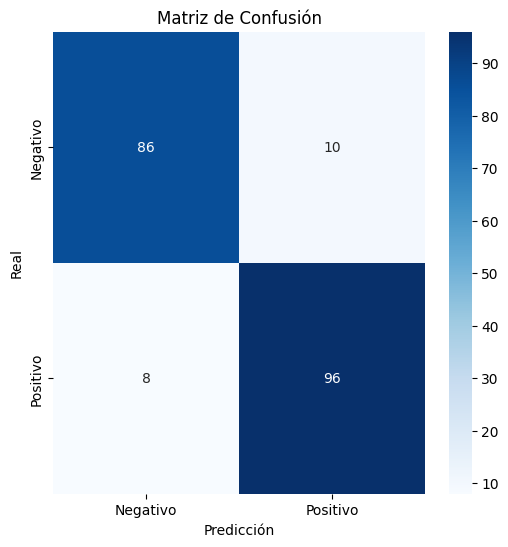

In [ ]:
# Matriz de confusión
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Negativo', 'Positivo'],
            yticklabels=['Negativo', 'Positivo'])
plt.xlabel('Predicción')
plt.ylabel('Real')
plt.title('Matriz de Confusión')
plt.show()

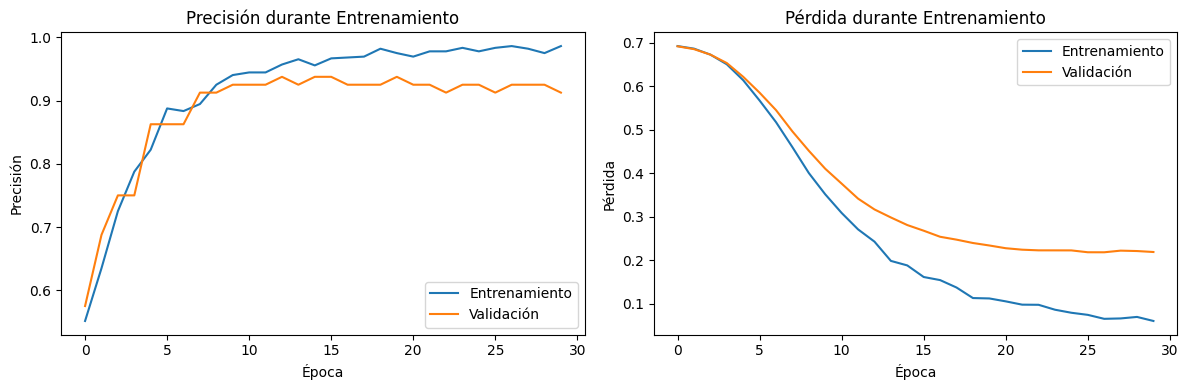

In [ ]:
# Gráficos de entrenamiento
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Entrenamiento')
plt.plot(history.history['val_accuracy'], label='Validación')
plt.title('Precisión durante Entrenamiento')
plt.ylabel('Precisión')
plt.xlabel('Época')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Entrenamiento')
plt.plot(history.history['val_loss'], label='Validación')
plt.title('Pérdida durante Entrenamiento')
plt.ylabel('Pérdida')
plt.xlabel('Época')
plt.legend()
plt.tight_layout()
plt.show()

##Tendencia principal:

- Rápido aprendizaje inicial: Precisión sube de ~0.5 a ~0.8 en primeras 5 épocas

- Estabilización: Alcanza ~0.9 en época 10 y se mantiene estable hasta época 25

##Relación entrenamiento-validación:

- Curvas casi superpuestas (entrenamiento y validación)

- Mínima brecha (<0.02) → No hay sobreajuste

- Validación ligeramente más alta en últimas épocas → Excelente generalización

# 8. Características más importantes


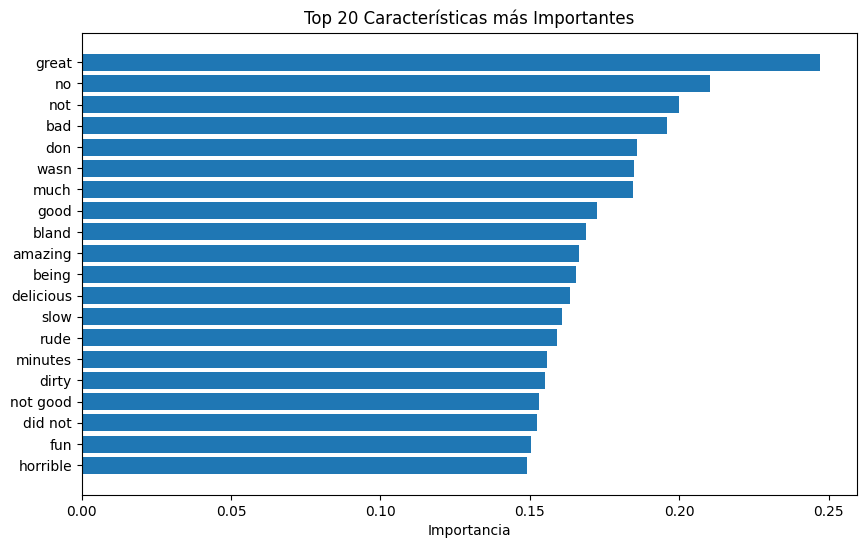

In [ ]:
weights = model.layers[0].get_weights()[0]
feature_names = tfidf.get_feature_names_out()[selector.get_support()]
importance = np.abs(weights).mean(axis=1).flatten()
top_indices = importance.argsort()[-20:][::-1]

plt.figure(figsize=(10, 6))
plt.barh([feature_names[i] for i in top_indices], importance[top_indices])
plt.xlabel('Importancia')
plt.title('Top 20 Características más Importantes')
plt.gca().invert_yaxis()
plt.show()
